# 05 — Hyperparameter Tuning
**Project**: YOLOv11s Person Detection  
**Tujuan**: Tingkatkan mAP@0.5 agar mencapai target ≥ 0.60

> Jalankan notebook ini **hanya jika** hasil evaluasi (notebook 04) belum memenuhi target.

---

## 5.1 Import & Load Hasil Sebelumnya

In [3]:
%matplotlib inline
import torch
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Load hasil evaluasi sebelumnya
with open('runs/eval_results.json') as f:
    prev_eval = json.load(f)

with open('runs/training_summary.json') as f:
    train_summary = json.load(f)

DATASET_YAML  = 'dataset/dataset.yaml'
DEVICE        = 0 if torch.cuda.is_available() else 'cpu'
CURRENT_MAP50 = prev_eval['test_map50']
TARGET_MAP50  = 0.60
SEED          = 42

print(f'mAP@0.5 saat ini : {CURRENT_MAP50:.4f}')
print(f'Target mAP@0.5   : {TARGET_MAP50}')
print(f'Gap yang perlu ditutup: {TARGET_MAP50 - CURRENT_MAP50:+.4f}')
print(f'\nStatus: {"Sudah mencapai target, tuning tidak diperlukan!" if CURRENT_MAP50 >= TARGET_MAP50 else "Belum mencapai target, lanjutkan tuning..."}')

mAP@0.5 saat ini : 0.7551
Target mAP@0.5   : 0.6
Gap yang perlu ditutup: -0.1551

Status: Sudah mencapai target, tuning tidak diperlukan!


## 5.2 Diagnosis: Identifikasi Masalah

In [4]:
# run_dir di-derive dari model_path yang sudah tersimpan di training_summary
# (menghindari masalah YOLO menambahkan prefix runs/detect/ secara otomatis)
run_dir     = Path(train_summary['model_path']).parent.parent  # .../weights/best.pt -> run dir
results_csv = run_dir / 'results.csv'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

# Analisis loss curves
final_train_box = df['train/box_loss'].iloc[-1] if 'train/box_loss' in df.columns else None
final_val_box   = df['val/box_loss'].iloc[-1]   if 'val/box_loss'   in df.columns else None
final_map50     = df['metrics/mAP50(B)'].iloc[-1] if 'metrics/mAP50(B)' in df.columns else None
max_map50       = df['metrics/mAP50(B)'].max()   if 'metrics/mAP50(B)' in df.columns else None
stopped_early   = len(df) < train_summary.get('total_epochs', 50)

print(f'Run dir: {run_dir}')
print('=== DIAGNOSIS ===')
print(f'Total epoch dijalankan : {len(df)} / {train_summary.get("total_epochs", 50)}')
print(f'Early stopping aktif   : {stopped_early}')
if max_map50:
    print(f'Best mAP@0.5 (val)     : {max_map50:.4f}')
if final_train_box and final_val_box:
    ratio = final_val_box / final_train_box
    print(f'Final train box loss   : {final_train_box:.4f}')
    print(f'Final val box loss     : {final_val_box:.4f}')
    print(f'Val/Train loss ratio   : {ratio:.2f}')
    if ratio > 1.5:
        print('\n OVERFITTING (val loss >> train loss)')
        print('  Solusi: tambah augmentasi, tambah weight_decay, kurangi epochs')
    elif final_val_box > 0.5:
        print('\n UNDERFITTING (val loss masih tinggi)')
        print('  Solusi: tambah epochs, turunkan lr, tingkatkan imgsz')
    else:
        print('\n Loss curve normal — coba fine-tune hyperparameter')
print('=================')


Run dir: runs\detect\runs\train\person_yolo11s_v1
=== DIAGNOSIS ===
Total epoch dijalankan : 50 / 50
Early stopping aktif   : False
Best mAP@0.5 (val)     : 0.7306
Final train box loss   : 0.8864
Final val box loss     : 1.1822
Val/Train loss ratio   : 1.33

 UNDERFITTING (val loss masih tinggi)
  Solusi: tambah epochs, turunkan lr, tingkatkan imgsz


## 5.3 Strategi Tuning

Pilih salah satu strategi berdasarkan diagnosis di atas:

### 5.3.1 Strategi A — Tambah Epochs (jika underfitting / early stopping terlalu cepat)

In [5]:
# ── STRATEGI A: Resume training dengan lebih banyak epoch ─────────────────────
# Aktifkan cell ini jika model berhenti terlalu cepat (early stopping) dan
# loss masih belum konvergen

STRATEGY = 'A'   # Ubah ke 'B' atau 'C' sesuai kebutuhan

if STRATEGY == 'A':
    print('Strategi A: Resume training dengan patience lebih besar & epochs lebih banyak')
    model_a = YOLO(train_summary['model_path'])

    results_a = model_a.train(
        data          = DATASET_YAML,
        imgsz         = 640,
        epochs        = 80,           # Tambah epochs
        batch         = 16,
        workers       = 4,
        optimizer     = 'SGD',
        lr0           = 0.001,        # LR lebih kecil untuk fine-tune
        lrf           = 0.01,
        momentum      = 0.937,
        weight_decay  = 0.0005,
        warmup_epochs = 1,
        patience      = 20,           # Patience lebih besar
        mosaic        = 1.0,
        fliplr        = 0.5,
        hsv_h         = 0.015,
        hsv_s         = 0.7,
        hsv_v         = 0.4,
        device        = DEVICE,
        seed          = SEED,
        project       = 'runs/tune',
        name          = 'strategy_A',
        exist_ok      = False,
    )
    print('Strategi A selesai!')

Strategi A: Resume training dengan patience lebih besar & epochs lebih banyak
New https://pypi.org/project/ultralytics/8.4.36 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.6  Python-3.12.10 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=r

c:\Users\naufa\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/04/09 23:45:57 INFO mlflow.tracking.fluent: Experiment with name 'runs/tune' does not exist. Creating a new experiment.


MLflow: logging run_id(ce4f89ca9e184a238eabe75f3af7fda3) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\NaufalFirdaus\CODES\AI\person-tracker-yolov11\files\runs\detect\runs\tune\strategy_A
Starting training for 80 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/80      3.97G     0.9821     0.6904      1.066         27        640: 100% ━━━━━━━━━━━━ 132/132 3.0it/s 44.4s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.5s/it 23.1s0.7s
                   all        450       1909      0.772      0.657      0.728      0.484

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/80      4.04G     0.9242     0.6605      1.041         32        640: 100% ━

### 5.3.2 Strategi B — Naikkan Resolusi Input (jika person kecil banyak tidak terdeteksi)

In [6]:
# ── STRATEGI B: Tingkatkan imgsz ke 832 ───────────────────────────────────────
# Efektif jika banyak person kecil (bbox < 32px) yang tidak terdeteksi
# Trade-off: batch size perlu dikurangi (lebih banyak memori)

if STRATEGY == 'B':
    print('Strategi B: imgsz=832 untuk deteksi objek kecil')
    model_b = YOLO(train_summary['model_path'])

    results_b = model_b.train(
        data          = DATASET_YAML,
        imgsz         = 832,          # Resolusi lebih tinggi
        epochs        = 50,
        batch         = 8,            # Kurangi batch karena memory lebih besar
        workers       = 4,
        optimizer     = 'SGD',
        lr0           = 0.01,
        lrf           = 0.01,
        momentum      = 0.937,
        weight_decay  = 0.0005,
        warmup_epochs = 3,
        patience      = 15,
        mosaic        = 1.0,
        fliplr        = 0.5,
        mixup         = 0.1,          # Aktifkan mixup
        hsv_h         = 0.015,
        hsv_s         = 0.7,
        hsv_v         = 0.4,
        device        = DEVICE,
        seed          = SEED,
        project       = 'runs/tune',
        name          = 'strategy_B',
        exist_ok      = False,
    )
    print('Strategi B selesai!')

### 5.3.3 Strategi C — Tambah Augmentasi (jika overfitting)

In [7]:
# ── STRATEGI C: Augmentasi agresif untuk kurangi overfitting ──────────────────

if STRATEGY == 'C':
    print('Strategi C: Augmentasi agresif + weight_decay lebih besar')
    model_c = YOLO(train_summary['model_path'])

    results_c = model_c.train(
        data          = DATASET_YAML,
        imgsz         = 640,
        epochs        = 60,
        batch         = 16,
        workers       = 4,
        optimizer     = 'AdamW',      # AdamW lebih stabil untuk regularisasi
        lr0           = 0.001,
        lrf           = 0.01,
        momentum      = 0.9,
        weight_decay  = 0.001,        # L2 regularization lebih kuat
        warmup_epochs = 3,
        patience      = 15,
        mosaic        = 1.0,
        mixup         = 0.15,         # MixUp
        copy_paste    = 0.1,          # Copy-paste augmentation
        degrees       = 10.0,         # Rotasi lebih besar
        scale         = 0.7,
        shear         = 2.0,
        perspective   = 0.0005,
        fliplr        = 0.5,
        flipud        = 0.0,
        hsv_h         = 0.02,
        hsv_s         = 0.8,
        hsv_v         = 0.5,
        erasing       = 0.5,          # Random erasing lebih banyak
        device        = DEVICE,
        seed          = SEED,
        project       = 'runs/tune',
        name          = 'strategy_C',
        exist_ok      = False,
    )
    print('Strategi C selesai!')

### 5.3.4 Strategi D — Auto Tuning (Ultralytics Built-in)

In [8]:
# ── STRATEGI D: Auto-tune dengan Ultralytics ──────────────────────────────────
# Paling optimal tapi paling lambat.
# Jalankan jika semua strategi manual belum membuahkan hasil.

if STRATEGY == 'D':
    print('Strategi D: Auto hyperparameter tuning (Ultralytics built-in)')
    print('Estimasi waktu: sangat lama (beberapa jam tergantung iterations)')
    print('\nMenginisialisasi model fresh untuk auto-tune...')

    model_tune = YOLO('yolo11s.pt')   # Start dari pretrained, bukan fine-tuned

    model_tune.tune(
        data       = DATASET_YAML,
        epochs     = 20,              # Epoch per trial (lebih kecil = lebih cepat)
        iterations = 30,              # Jumlah trial (kombinasi hyperparameter)
        optimizer  = 'AdamW',
        plots      = True,
        save       = True,
        val        = True,
        device     = DEVICE,
        project    = 'runs/tune',
        name       = 'auto_tune',
    )
    print('Auto-tune selesai! Cek runs/tune/auto_tune/ untuk hasil terbaik.')

## 5.4 Evaluasi Hasil Tuning (Bandingkan Semua Strategi)

In [13]:
# Auto-detect tune_dir (YOLO mungkin menyimpan di runs/detect/runs/tune/...)
tune_dir = Path('runs/tune') / f'strategy_{STRATEGY}'
if not tune_dir.exists():
    found = list(Path('runs').rglob(f'strategy_{STRATEGY}/weights/best.pt'))
    if found:
        tune_dir = found[0].parent.parent
        print(f'[INFO] tune_dir dikoreksi -> {tune_dir}')

tune_dir = Path('runs/tune') / f'strategy_{STRATEGY}'
tuned_model_path = tune_dir / 'weights' / 'best.pt'

if tuned_model_path.exists():
    tuned_model = YOLO(tuned_model_path)

    tuned_metrics = tuned_model.val(
        data    = DATASET_YAML,
        split   = 'val',
        imgsz   = 640,
        batch   = 16,
        device  = DEVICE,
        conf    = 0.25,
        iou     = 0.5,
        verbose = False
    )

    tuned_map50   = tuned_metrics.box.map50
    tuned_map5095 = tuned_metrics.box.map
    tuned_prec    = tuned_metrics.box.mp
    tuned_rec     = tuned_metrics.box.mr

    print('=' * 55)
    print(f'  PERBANDINGAN: Sebelum vs Sesudah Tuning (Strategi {STRATEGY})')
    print('=' * 55)
    print(f'{"Metrik":20s} {"Sebelum":>10s} {"Sesudah":>10s} {"Delta":>8s}')
    print('-' * 55)
    print(f'{"mAP@0.5":20s} {CURRENT_MAP50:>10.4f} {tuned_map50:>10.4f} {tuned_map50-CURRENT_MAP50:>+8.4f}')
    print(f'{"mAP@0.5:0.95":20s} {prev_eval["test_map5095"]:>10.4f} {tuned_map5095:>10.4f} {tuned_map5095-prev_eval["test_map5095"]:>+8.4f}')
    print(f'{"Precision":20s} {prev_eval["test_precision"]:>10.4f} {tuned_prec:>10.4f} {tuned_prec-prev_eval["test_precision"]:>+8.4f}')
    print(f'{"Recall":20s} {prev_eval["test_recall"]:>10.4f} {tuned_rec:>10.4f} {tuned_rec-prev_eval["test_recall"]:>+8.4f}')
    print('=' * 55)
    print(f'Target ≥ 0.60: {"TERCAPAI ✓" if tuned_map50 >= 0.60 else "BELUM TERCAPAI ✗"}')

    if tuned_map50 >= 0.60:
        # Update training summary dengan model terbaik baru
        train_summary['model_path']      = str(tuned_model_path)
        train_summary['best_map50']      = float(tuned_map50)
        train_summary['tuning_strategy'] = STRATEGY
        with open('runs/training_summary.json', 'w') as f:
            json.dump(train_summary, f, indent=2)
        print(f'\nModel terbaik diupdate: {tuned_model_path}')
        print('→ Lanjutkan ke 06_visualization.ipynb')
    else:
        print('\n→ Coba strategi lain atau ulangi dengan parameter berbeda')
else:
    print(f'Model dari strategi {STRATEGY} tidak ditemukan di {tuned_model_path}')
    print('Pastikan cell training di atas sudah dijalankan.')

Model dari strategi A tidak ditemukan di runs\tune\strategy_A\weights\best.pt
Pastikan cell training di atas sudah dijalankan.


## 5.5 Plot Perbandingan Training Curves

[INFO] Strategi A belum dijalankan — hanya menampilkan kurva Original.


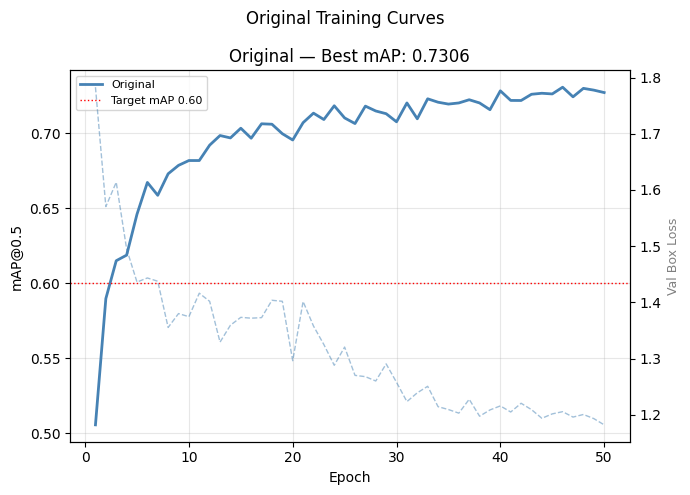

Plot disimpan ke runs\detect\runs\train\person_yolo11s_v1/comparison_curves.png


In [12]:
run_dir_orig = Path(train_summary['model_path']).parent.parent

# Cek tune_dir — hanya masukkan ke plot jika results.csv benar-benar ada
try:
    _tuned_csv = tune_dir / 'results.csv'
    run_dir_tuned = tune_dir if _tuned_csv.exists() else None
except NameError:
    run_dir_tuned = None

# Bangun list plot hanya dari data yang tersedia
plot_targets = [(run_dir_orig, 'Original', 'steelblue')]
if run_dir_tuned:
    plot_targets.append((run_dir_tuned, f'Strategi {STRATEGY}', 'coral'))
else:
    print(f'[INFO] Strategi {STRATEGY} belum dijalankan — hanya menampilkan kurva Original.')

n_plots = len(plot_targets)
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
if n_plots == 1:
    axes = [axes]
title = 'Original vs Strategi ' + STRATEGY if run_dir_tuned else 'Original Training Curves'
fig.suptitle(title, fontsize=12)

col = 'metrics/mAP50(B)'

for ax, (rdir, label, color) in zip(axes, plot_targets):
    csv = rdir / 'results.csv'
    df_run = pd.read_csv(csv)
    df_run.columns = df_run.columns.str.strip()
    epochs = range(1, len(df_run) + 1)
    if col in df_run.columns:
        ax.plot(epochs, df_run[col], color=color, linewidth=2, label=label)
    if 'val/box_loss' in df_run.columns:
        ax2 = ax.twinx()
        ax2.plot(epochs, df_run['val/box_loss'], color=color, linewidth=1,
                 linestyle='--', alpha=0.5, label='val box loss')
        ax2.set_ylabel('Val Box Loss', color='gray', fontsize=9)
    ax.axhline(0.60, color='red', linestyle=':', linewidth=1, label='Target mAP 0.60')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP@0.5')
    best_val = f'{df_run[col].max():.4f}' if col in df_run.columns else 'N/A'
    ax.set_title(f'{label} — Best mAP: {best_val}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_dir = run_dir_tuned if run_dir_tuned else run_dir_orig
plt.savefig(save_dir / 'comparison_curves.png', dpi=100)
plt.show()
print(f'Plot disimpan ke {save_dir}/comparison_curves.png')


---
## ✅ Ringkasan Notebook 05

| Strategi | Kondisi | Perubahan Utama |
|----------|---------|------------------|
| A | Underfitting / early stop | Tambah epochs, patience |
| B | Objek kecil tidak terdeteksi | imgsz=832 |
| C | Overfitting | Augmentasi agresif, weight_decay |
| D | Semua manual gagal | Auto-tune Ultralytics |

**Langkah selanjutnya** → `06_visualization.ipynb`